In [2]:
%run "./crop.ipynb"
import os
import torch
from model import model_final as model,device
from dataset import test_transform as transform
from torch.amp import autocast 
import torch.nn.functional as F


Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

In [2]:
base_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test"
input_path = os.path.join(base_path,"input")
for filename in os.listdir(input_path):
    input_files=os.path.join(input_path,filename)
    output_dir=os.path.join(base_path,"input_processed")
    os.makedirs(output_dir, exist_ok=True)
    output_files = os.path.join(output_dir, filename.split('.')[0] + ".PNG")
    crop_and_save_signature(input_files,output_files)

In [62]:
img_ref_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test\input_processed\ref_02.PNG"
img_query_path = r"C:\Users\gupta\7th SEM\Project\Signature\real_test\input_processed\gen_02.PNG"
img_ref = Image.open(img_ref_path).convert('L')
img_query =Image.open(img_query_path).convert('L')
img_ref = transform(img_ref)
img_query = transform(img_query)

In [63]:
margin = 1.2
lr = 0.001
# best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"
best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_focal_dynamic_margin{margin}_lr{lr}.pt"
# best_model_path='best_model_optimized.pt'

In [66]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
threshold = 0.432
with torch.no_grad():
        img1 = img_ref.unsqueeze(0).to(device, non_blocking=True)
        img2 = img_query.unsqueeze(0).to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        result = "Genuine" if distance < threshold else "Forgery"
        print(result,distance)

Forgery tensor([0.4470], device='cuda:0')


C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


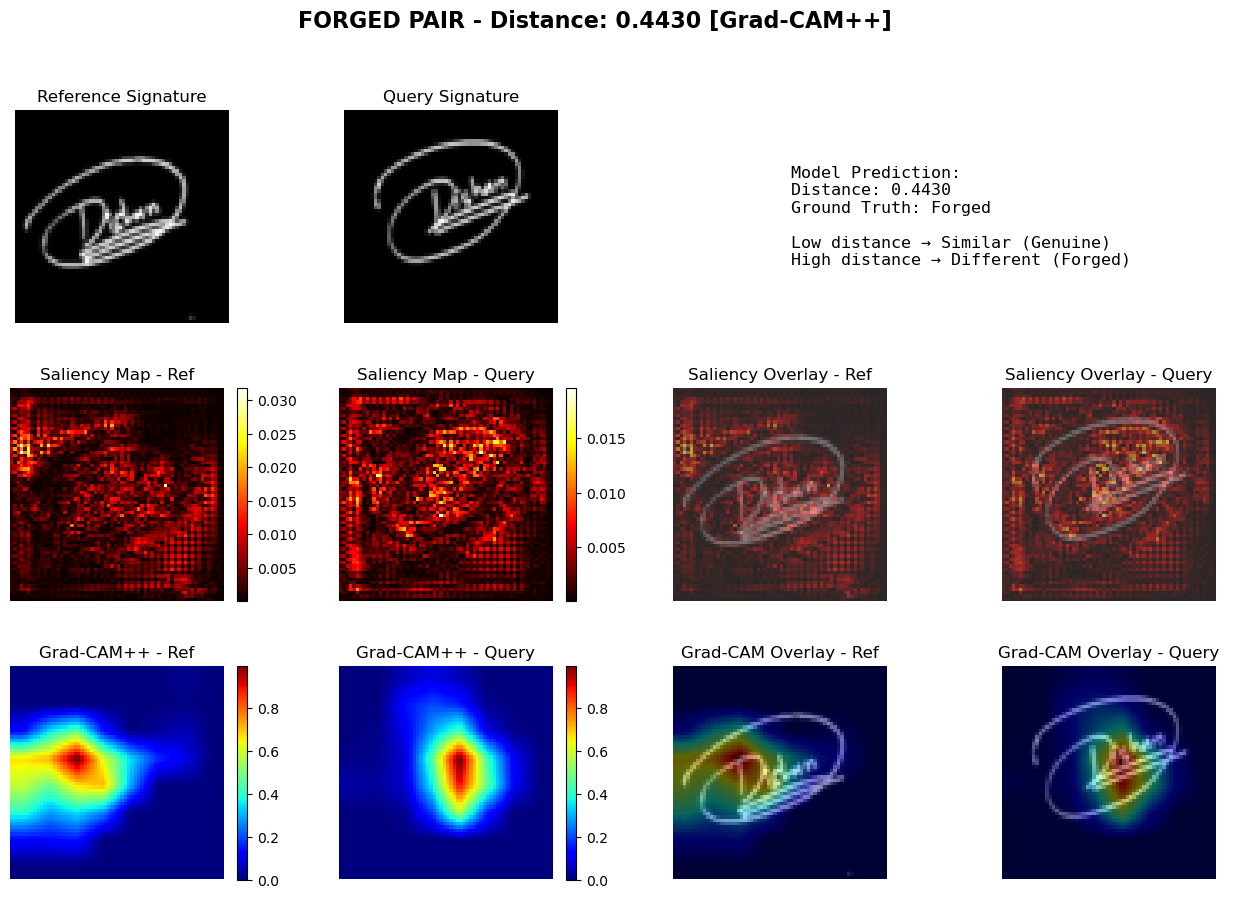

In [67]:
from saliency_visualization import SaliencyVisualizer, analyze_model_focus
visualizer = SaliencyVisualizer(model, device)

visualizer.visualize_pair(
    img1, 
    img2, 
    0)